What is the motivation for this session? What questions does it answer?

- What do I do when I have a large dataset and run out of memory during training?
  - You batch the data.
- How do I batch the data efficiently?
  - Use torch.util.data's DataLoader
    - TensorDataset to create a Dataset class from tensors that can be read by DataLoader and Dataset to create a custom dataset class (advanced topic)
- How should I make sure that the model doesn't just memorize the training data and can't generalize to unseen data?
  - Split into train (and validation) and test data

New Order
- Train, val, test splitting sections 1-3
- Dataloader & Dataset section 4


In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Section 1: Batching Data to Train Efficiently

If your dataset is large, you might run out of memory during training. 

| Code | Description |
|---|---|
| `DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |
| `DataLoader(dataset, batch_size = some_num)` | Create a DataLoader for `dataset` where the size of each batch set to `some_num` (default batchsize is 1). |
| `DataLoader(dataset, batch_size = some_num, drop_last = True)` | Create a DataLoader for `dataset` and drop last batch if it's not the same size as the other batches. |
| `DataLoader(dataset, shuffle = True)` | Create a DataLoader for `dataset` and reshuffle the data at each iteration (epoch) during training. |
| `dataloader = DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |

#### **Exercises**

In [4]:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
df = pd.read_csv(url)

# the data in the wine column are the labels
labels = df['Wine'].values

# the data from all other columns are the features
features = df.drop(columns='Wine').values

features_orig = torch.tensor(features, dtype=torch.float32)
labels_orig = torch.tensor(labels, dtype=torch.long)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
dataset = TensorDataset(features_orig, labels_orig)

**Example**: Create a dataloader using the TensorDataset variable `dataset` created above. Then run the cell below where the dataloader is looped through and the dimensions of the features in each batch are printed. How big is the sample in each batch?

In [6]:
dataloader = DataLoader(dataset)

In [7]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 4:
        break

Batch nr: 0, number of samples in batch: 1, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 1, total number of samples looped through: 1
Batch nr: 2, number of samples in batch: 1, total number of samples looped through: 2
Batch nr: 3, number of samples in batch: 1, total number of samples looped through: 3
Batch nr: 4, number of samples in batch: 1, total number of samples looped through: 4
Batch nr: 5, number of samples in batch: 1, total number of samples looped through: 5


By default, the batch size in the dataloader is `1`.

**Exercise**: Create a dataloader with batch size `8`. Then, run the cell below with the loop going through the batches.

In [8]:
dataloader = DataLoader(dataset, batch_size=8)

In [9]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 8, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 8, total number of samples looped through: 8
Batch nr: 2, number of samples in batch: 8, total number of samples looped through: 16
Batch nr: 3, number of samples in batch: 8, total number of samples looped through: 24
Batch nr: 4, number of samples in batch: 8, total number of samples looped through: 32
Batch nr: 5, number of samples in batch: 8, total number of samples looped through: 40
Batch nr: 6, number of samples in batch: 8, total number of samples looped through: 48


**Exercise**: Create a dataloader with batch size `50` and run the cell with the loop.

In [12]:
dataloader = DataLoader(dataset, batch_size=50)

In [13]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100
Batch nr: 3, number of samples in batch: 28, total number of samples looped through: 150


The last batch in this dataset has `28` samples when the batch size is set to 50. That's because the total number of samples in the dataset is 178, and 178-150 = 28. There aren't enough samples left to fill up a batch size of 50 in the last iteration.

**Exercise**: Create the dataloader with a batch size of 50 again, but set `drop_last=True`. What happens to the last batch in the loop?

In [14]:
dataloader = DataLoader(dataset, batch_size=50, drop_last=True)

In [15]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100


If the last batch is smaller than the others, it's dropped when `drop_last` is set to `True`. A useful feature PyTorch's `DataLoader` is that you don't have to add extra code to handle special cases like this yourself when you loop through the batches, the `DataLoader` does it for you. It can also take care of other things like shuffling your data.

**Exercise**: Run the cell below where a dataloader is created with the default batch size and without shuffling. Do you get the same output when you run the cell again?

In [20]:
dataloader = DataLoader(dataset)

feature, label = next(iter(dataloader))
feature, label

(tensor([[1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
          3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
          1.0650e+03]]),
 tensor([1]))

You should get the same feature values and label in the previous exercise no matter how many times you reran the code cell.

**Exercise**: Create a dataloader for the dataset again, but this time, set the parameter `shuffle = True`. Then run the cell below that gets a set of features and their label from the dataset. Do you get the same values when you run it repeatedly now?

In [21]:
dataloader = DataLoader(dataset, shuffle=True)

In [23]:
feature, label = next(iter(dataloader))
feature, label

(tensor([[ 12.2200,   1.2900,   1.9400,  19.0000,  92.0000,   2.3600,   2.0400,
            0.3900,   2.0800,   2.7000,   0.8600,   3.0200, 312.0000]]),
 tensor([2]))

## Section 2: Train with a Dataloader

In [ ]:
class Model(nn.Module):
    def __init__(self,):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16,13)
        )

    def forward(self, x):
        output = self.layers(x)
        return output
    
Model()

Model(
  (layers): Sequential(
    (0): Linear(in_features=13, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=13, bias=True)
  )
)

In [215]:
model = Model()

In [216]:
dataloader = DataLoader(dataset, batch_size=20, shuffle=True)

Train with batching

In [217]:
model = Model()

nepochs = 200

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_function = nn.CrossEntropyLoss()

losses = []
accuracies = []
for epoch in tqdm(range(nepochs)):

    batch_losses, batch_accuracies = [], []
    for batch_idx, (features, labels) in enumerate(dataloader):

        optimizer.zero_grad()

        output = model.forward(features)

        loss = loss_function(output, labels)
        batch_losses.append(loss.item())

        loss.backward()

        optimizer.step()

        with torch.no_grad():
            accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
            batch_accuracies.append(accuracy)



    losses.append(np.mean(batch_losses))
    accuracies.append(np.mean(batch_accuracies))

  2%|▏         | 3/200 [00:00<00:07, 24.87it/s]

100%|██████████| 200/200 [00:04<00:00, 41.55it/s]


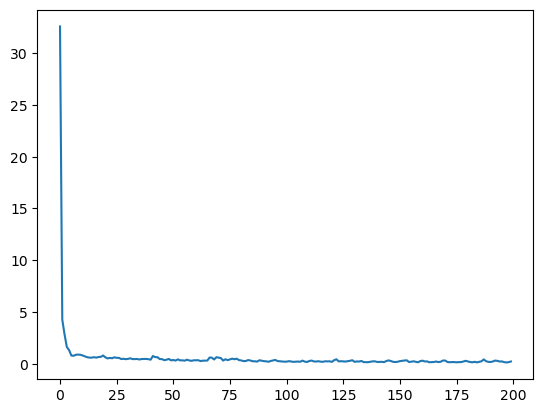

In [218]:
plt.plot(losses)

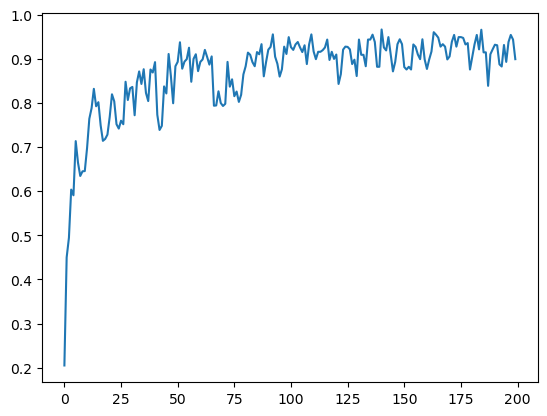

In [219]:
plt.plot(accuracies)

#### Test

In [220]:
train_fraction = 0.8
test_fraction = 0.2

train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction])

In [221]:
dataloader = DataLoader(train_data, batch_size=20, shuffle=True)

In [222]:
model = Model()

nepochs = 200

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_function = nn.CrossEntropyLoss()

losses = []
accuracies = []
for epoch in tqdm(range(nepochs)):

    batch_losses, batch_accuracies = [], []
    for batch_idx, (features, labels) in enumerate(dataloader):

        optimizer.zero_grad()

        output = model.forward(features)

        loss = loss_function(output, labels)
        batch_losses.append(loss.item())

        loss.backward()

        optimizer.step()

        #with torch.no_grad():
        accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
        batch_accuracies.append(accuracy)



    losses.append(np.mean(batch_losses))
    accuracies.append(np.mean(batch_accuracies))

100%|██████████| 200/200 [00:03<00:00, 51.26it/s]


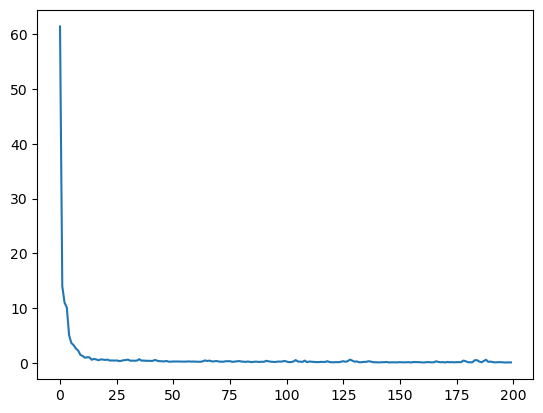

In [223]:
plt.plot(losses)

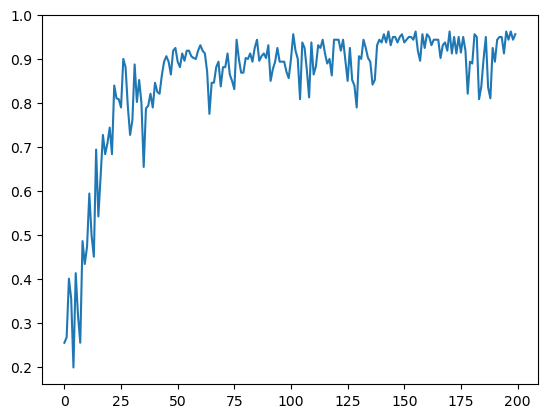

In [224]:
plt.plot(accuracies)

In [225]:
dataloader = DataLoader(test_data, batch_size=20, shuffle=True)

In [226]:
with torch.no_grad():
    test_accuracies = []
    for batch_idx, (features, labels) in enumerate(dataloader):

        output = model(features)

        accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
        test_accuracies.append(accuracy)

np.mean(test_accuracies)

np.float32(0.94166666)

## Section 3: Split data into train, validation, and test data.

| Code | Description |
|---|---|
| `subdatasetA, subdatasetB, ... = random_split(dataset, lengths = [fractionA, fractionB, ...])` | Splits the data in `dataset` into subdatasets. The fractions in `lengths` specifies the proportion of the data that should go into each subset. |
| `torch.Generator().manual_seed(some_num)` | Sets the seed. |
| `subdatasetA, subdatasetB, ... = random_split(NameDataset(), lengths = [fractionA, fractionB, ...], generator=some_torch_generator)` | The parameter `generator` can be fixed to make sure that the data is split in exactly the same way each time. This ensures reproducibility. |

#### **Exercises**

**Example**: Split the dataset into only two subsets: a train and a test subset. Set the fraction of the data going into the train dataset to 0.8 and the fraction going into test subset to 0.2.

In [24]:
train_fraction = 0.8
test_fraction = 0.2

train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

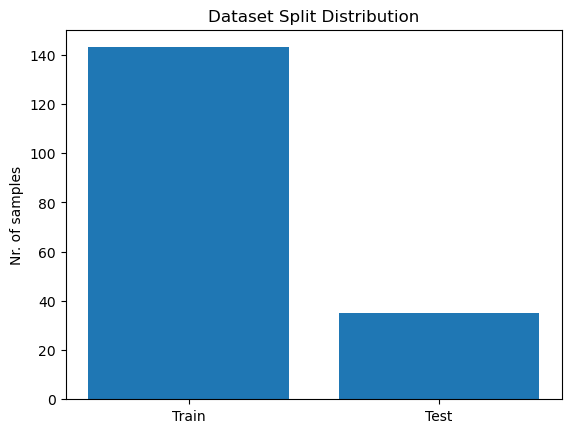

In [25]:
plt.bar(['Train', 'Test'], [len(train_data), len(test_data)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Split the dataset into three subsets according to the fractions provided below. One subset is used for training the model, one for validation during training - i.e. to train hyperparameters, and the last subset is used to test the final model.

In [ ]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

In [ ]:
train_data, val_data, test_data = random_split(dataset, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

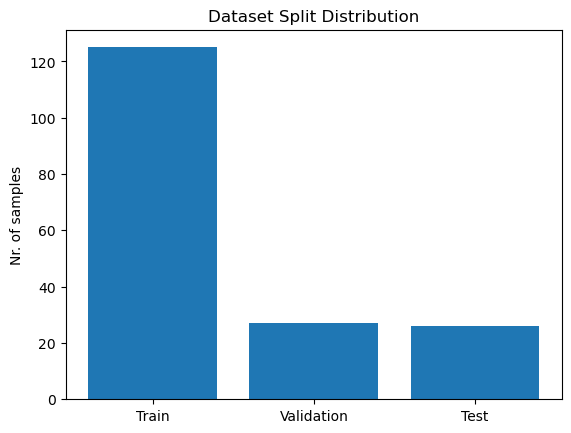

In [101]:
plt.bar(['Train', 'Validation', 'Test'], [len(train_data), len(val_data), len(test_data)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Set the fraction of the data going into the train dataset to `0.8` and the fractions going into the validation and test subsets to `0.1`. Then, split the data again and run the cell plotting the number of samples in each subdataset.

In [102]:
train_fraction = 0.8
val_fraction = 0.1
test_fraction = 1-train_fraction-val_fraction

train_data, val_data, test_data = random_split(dataset, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

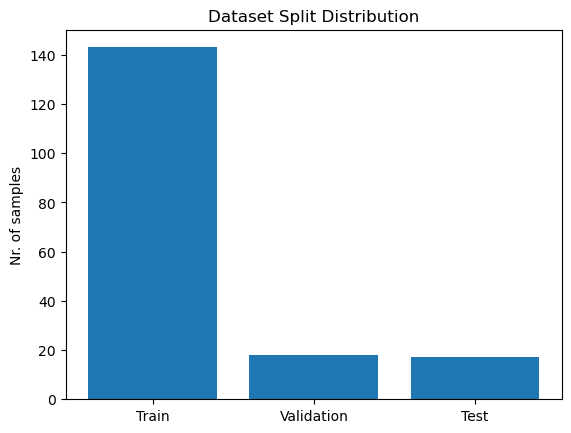

In [103]:
plt.bar(['Train', 'Validation', 'Test'], [len(train_data), len(val_data), len(test_data)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

As the name suggests, the `random_split` function splits the data randomly each time it's run. This means that even though the proportions are the same, you'll have different samples in the train, validation, and test subsets each time you run the code to split the data. To ensure reproducibility - that you get the same result each time you train the model on your data, you have to provide a random number generator with a fixed seed to the function.

**Exercise**: In the cell below, the data is split without providing a generator. Run the code in the cell below where features and a label fetched from the training subset is displayed after splitting. Do you get the same or different values when you run the code repeatedly?

In [ ]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

train_data, val_data, test_data = random_split(dataset, lengths=[train_fraction, val_fraction, test_fraction])

train_data[0]

**Exercise**: Create a PyTorch Pseudorandom Number Generator from the seed below.

In [ ]:
SEED = 42

In [ ]:
SEED = 42
generator = torch.Generator().manual_seed(SEED)
generator

**Exercise**: Create a PyTorch Generator from the seed below. Then, run the cell below where the data is split with the generator passed to the `random_split` function. Do you get the same or different values when you run the code repeatedly?

In [32]:
SEED = 2026

In [56]:
generator = torch.Generator().manual_seed(SEED)

train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

train_data, val_data, test_data = random_split(dataset, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)

train_data[0]

(tensor([1.4220e+01, 3.9900e+00, 2.5100e+00, 1.3200e+01, 1.2800e+02, 3.0000e+00,
         3.0400e+00, 2.0000e-01, 2.0800e+00, 5.1000e+00, 8.9000e-01, 3.5300e+00,
         7.6000e+02]),
 tensor(1))

## Section 4: Creating Custom Dataset Classes

| Code | Description |
|---|---|
| `class CustomDataset(Dataset):` | Create a custom dataset class that inherits from PyTorch's `Dataset` base class. |
| `def __init__(self):` | Initialize the dataset - load data, extract features and labels, and convert to tensors. |
| `def __len__(self):` | Define a method that returns the total number of samples in the dataset. |
| `def __getitem__(self, index):` | Define a method that returns the features and label at a specific index. |
| `dataset = CustomDataset()` | Create an instance of your custom dataset class. |

#### **Exercises**

**Example**: Make a custom class named `TitanicDataset`. The ``__init__`` function of the class should load the titanic data, extract the data in the columns `age` and `fare` to be used as features, and extract the data in the `survived` column to be used as labels. The `__len__` and `__getitem__` functions should return the number of samples (passengers) in the data and the data at a given ``index``, respectively.

In [ ]:
class TitanicDataset(Dataset):
    def __init__(self):
        '''Load dataset and extract features and labels'''
        super().__init__()

        # load the data
        df_titanic = pd.read_csv('data/raw/titanic.csv')

        # extract features and labels and turn them into tensors
        self.features = torch.tensor(df_titanic[['age', 'fare']].values, dtype = torch.float32)
        self.labels = torch.tensor(df_titanic['survived'].values, dtype=torch.long)

    def __len__(self):
        '''Get the number of samples in the dataset'''
        return len(self.labels)
    
    def __getitem__(self, index):
        '''Get the item and a given index in the dataset'''
        return self.features[index], self.labels[index]


In [ ]:
titanic = TitanicDataset()
titanic

**Excercise**: Make a custom class named `WineDataset`. The ``__init__`` function of the class should load the wine data and extract the same data to be used as features and labels as in section 1 above. The `__len__` and `__getitem__` functions should return the number of samples (wines) in the data and the data at a given ``index``, respectively.

In [ ]:
class WineDataset(Dataset):
    def __init__(self):
        # load data
        df = pd.read_csv('data/raw/wine.csv')

        self.features = torch.tensor(df.drop(columns = 'Wine').values, dtype=torch.float32)
        self.labels = torch.tensor(df['Wine'].values, dtype = torch.long) - 1 # subtract 1 to start at 0

    def __len__(self):
        '''Get the number of samples in the dataset'''
        return len(self.labels)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
wine = WineDataset()
wine